In [5]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

# -----------------------------------------------------------------------------
# 1) Load & prepare data
# -----------------------------------------------------------------------------
parsec_data  = pd.read_csv('Isochrones/PARSEC_EDR3_solar.dat', sep='\s+', low_memory=False)
baraffe_data = pd.read_csv('baraffe.csv', sep=',')

# Convert ages
parsec_data['Age']  = 10 ** parsec_data['logAge'] / 1e6
baraffe_data['Age'] = 10 ** baraffe_data['Age']    / 1e6
baraffe_data['Mass'] = baraffe_data['M/Ms']

# Global mass grid (0.1 M⊙)
m_low  = max(parsec_data['Mass'].min(), baraffe_data['Mass'].min())
m_high = min(parsec_data['Mass'].max(), baraffe_data['Mass'].max())
mass_grid = np.round(np.arange(m_low, m_high + 1e-6, 0.1), 1)

# Baraffe age grids
orig_ages = np.sort(baraffe_data['Age'].unique())
fine_ages = np.arange(orig_ages.min(), orig_ages.max() + 1, 0.25)

# Precompute Baraffe sequences on mass_grid
bp_rp_arr = []
gmag_arr  = []
for age in orig_ages:
    df = baraffe_data[baraffe_data['Age'] == age]
    f_bp = interp1d(df['Mass'], df['BP_RP'], kind='linear',
                    bounds_error=False, fill_value=np.nan)
    f_g  = interp1d(df['Mass'], df['Gmag'], kind='linear',
                    bounds_error=False, fill_value=np.nan)
    bp_rp_arr.append(f_bp(mass_grid))
    gmag_arr .append(f_g (mass_grid))
bp_rp_arr = np.vstack(bp_rp_arr)
gmag_arr  = np.vstack(gmag_arr)

# Interpolators: age → (BP−RP, G) on mass_grid
t_bp = interp1d(orig_ages, bp_rp_arr, axis=0,
                kind='linear', bounds_error=False, fill_value=np.nan)
t_g  = interp1d(orig_ages, gmag_arr,  axis=0,
                kind='linear', bounds_error=False, fill_value=np.nan)

# List of PARSEC ages
parsec_ages = np.unique(parsec_data['Age'])

# -----------------------------------------------------------------------------
# 2) Worker function: for one PARSEC age, find the best Baraffe age + return plotting data
# -----------------------------------------------------------------------------
def match_one_age(parsec_age):
    df_p     = parsec_data[parsec_data['Age'] == parsec_age]
    m_p_min  = df_p['Mass'].min()
    # Baraffe ceiling
    df_b_same = baraffe_data[np.isclose(baraffe_data['Age'], parsec_age)]
    if df_b_same.empty:
        nearest   = orig_ages[np.abs(orig_ages - parsec_age).argmin()]
        df_b_same = baraffe_data[baraffe_data['Age'] == nearest]
    m_b_max = df_b_same['Mass'].max()

    # Slice PARSEC to [m_p_min, m_b_max]
    df_p_sub = df_p[(df_p['Mass'] >= m_p_min) & (df_p['Mass'] <= m_b_max)]
    c_p = (df_p_sub['G_BPmag'] - df_p_sub['G_RPmag']).values
    m_p = df_p_sub['Gmag'].values
    order_p = np.argsort(c_p)
    c_p, m_p = c_p[order_p], m_p[order_p]

    # Uniform color grid
    N = 100
    c_min, c_max = c_p.min(), c_p.max()
    c_grid = np.linspace(c_min, c_max, N)
    m_p_grid = interp1d(c_p, m_p, bounds_error=False, fill_value=np.nan)(c_grid)

    # Mask mass grid
    mask = (mass_grid >= m_p_min) & (mass_grid <= m_b_max)

    # Compute χ² for each fine age
    chi2 = []
    for age_b in fine_ages:
        bp_all = t_bp(age_b)[mask]
        g_all  = t_g (age_b)[mask]
        in_dom = (bp_all >= c_min) & (bp_all <= c_max)
        bp_b, g_b = bp_all[in_dom], g_all[in_dom]
        if len(bp_b) < 5:
            chi2.append(np.inf)
            continue
        order_b = np.argsort(bp_b)
        bp_b, g_b = bp_b[order_b], g_b[order_b]
        m_b_grid = interp1d(bp_b, g_b, bounds_error=False, fill_value=np.nan)(c_grid)
        chi2.append(np.nansum((m_p_grid - m_b_grid)**2))

    chi2      = np.array(chi2)
    best_idx  = np.nanargmin(chi2)
    best_age  = fine_ages[best_idx]

    # Re-extract best‐match for plotting
    bp_all = t_bp(best_age)[mask]
    g_all  = t_g (best_age)[mask]
    in_dom = (bp_all >= c_min) & (bp_all <= c_max)
    bp_b, g_b = bp_all[in_dom], g_all[in_dom]
    order_b = np.argsort(bp_b)
    bp_b, g_b = bp_b[order_b], g_b[order_b]
    m_b_best = interp1d(bp_b, g_b, bounds_error=False, fill_value=np.nan)(c_grid)

    # Return everything needed
    return {
        'parsec_age': parsec_age,
        'best_age':   best_age,
        'c_grid':     c_grid,
        'm_p':        m_p,
        'c_p':        c_p,
        'm_p_grid':   m_p_grid,
        'm_b_best':   m_b_best,
        'm_p_min':    m_p_min,
        'm_b_max':    m_b_max,
        'chi2':       chi2[best_idx],
    }

# -----------------------------------------------------------------------------
# 3) Parallel execution
# -----------------------------------------------------------------------------
results = []
with ProcessPoolExecutor() as exe:
    futures = { exe.submit(match_one_age, age): age for age in parsec_ages[:len(parsec_ages)-1]}
    for fut in as_completed(futures):
        results.append(fut.result())

# Sort by parsec_age
results.sort(key=lambda x: x['parsec_age'])

# Build mapping dict
best_age_mapping = { r['parsec_age']: r['best_age'] for r in results }

from matplotlib.backends.backend_pdf import PdfPages




In [6]:
parsec_ages

array([  1.        ,   1.49999565,   2.00000002,   2.49999995,
         2.99999133,   3.50001576,   4.00000008,   4.49997395,
         4.99999995,   5.49996594,   5.99998273,   6.49994976,
         7.00003159,   7.49997818,   8.00000024,   8.50002103,
         8.999948  ,   9.49992114,  10.        ,  10.50001695,
        10.99993199,  11.50005719,  11.99996557,  12.49999963,
        12.99989965,  13.49988286,  14.00006332,  14.5000667 ,
        14.99995651,  15.49993939,  16.00000064,  16.49985015,
        17.00004222,  17.50007863,  17.99989617,  18.49992637,
        18.99984246,  19.49979295,  20.0000002 ,  20.49981775,
        21.0000341 ,  21.50007624,  21.9998642 ,  22.49986954,
        23.0001146 ,  23.50011567,  23.99993138,  24.5002209 ,
        24.9999995 ,  25.49998941,  25.99979957,  26.50025177,
        26.99976598,  27.49982942,  28.00012692,  28.49968107,
        29.00013369,  29.49986306,  29.99991333,  30.50001128,
        30.99987909,  31.49995983,  32.0000016 ,  32.49

In [7]:
# -----------------------------------------------------------------------------
# 4) Save all comparisons into a single multi‑page PDF
# -----------------------------------------------------------------------------
with PdfPages('isochrone_comparisons.pdf') as pdf:
    for r in results:
        pa = r['parsec_age']
        ba = r['best_age']
        c_p, m_p = r['c_p'], r['m_p']
        c_grid    = r['c_grid']

        # create a new figure for this page
        fig = plt.figure(figsize=(6, 8))
        plt.scatter(c_p[1:], m_p[1:], s=10, alpha=0.6, label='PARSEC (slice)')
        plt.plot(c_grid[12:], r['m_p_grid'][12:], '--', label='PARSEC (grid)')
        plt.plot(c_grid, r['m_b_best'], '-', label=f'Baraffe {ba:.1f} Myr')
        plt.gca().invert_yaxis()
        plt.xlabel('BP - RP')
        plt.ylabel('Gmag')
        plt.title(
            f'PARSEC {pa:.1f} Myr vs. Baraffe {ba:.1f} Myr\n'
            f'mass ∈ [{r["m_p_min"]:.2f}, {r["m_b_max"]:.2f}] M⊙\n'
            f'χ² = {r["chi2"]:.1f}'
        )
        plt.legend()
        plt.tight_layout()

        # save this figure as a new page of the PDF
        pdf.savefig(fig)
        plt.close(fig)

print("Written all comparisons to 'isochrone_comparisons.pdf'")

Written all comparisons to 'isochrone_comparisons.pdf'


In [39]:
r['m_p_grid'][12:]

array([ 3.26508054,  3.476913  ,  3.70541933,  3.92927489,  4.15039302,
        4.36552482,  4.57175815,  4.77104229,  4.96582655,  5.15802178,
        5.34159311,  5.52101036,  5.70164266,  5.87659259,  6.03596296,
        6.19477512,  6.34461377,  6.49441302,  6.63144086,  6.754375  ,
        6.86963393,  6.98489286,  7.09840587,  7.21001609,  7.32162631,
        7.43323654,  7.54484676,  7.66655995,  7.78939482,  7.91222969,
        8.03654545,  8.18592873,  8.31633333,  8.42063293,  8.5345418 ,
        8.65079664,  8.76417673,  8.87630821,  8.98843969,  9.12278182,
        9.25806553,  9.39334924,  9.52903598,  9.66576852,  9.80250105,
        9.93923359, 10.07761691, 10.21605986, 10.35450281, 10.48942516,
       10.62377043, 10.75348788, 10.87233608, 10.9903882 , 11.10844033,
       11.22649246, 11.318622  , 11.40821879, 11.49781559, 11.58741239,
       11.67700919, 11.76660599, 11.85449257, 11.94091052, 12.02732846,
       12.11374641, 12.19705432, 12.27851029, 12.35996626, 12.43

In [7]:
best_ages = list(best_age_mapping.values())

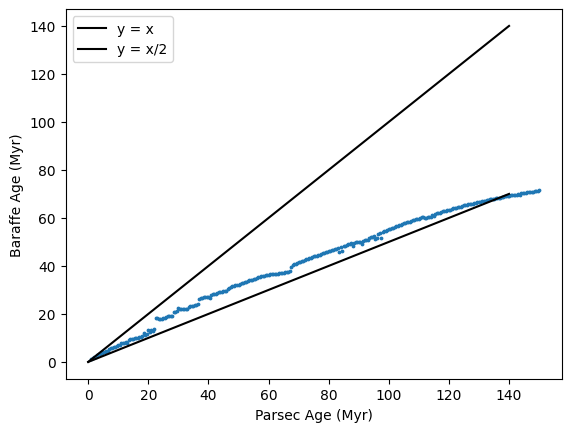

In [15]:
plt.scatter(best_age_mapping.keys(), best_age_mapping.values(), s = 3)
plt.plot(np.linspace(0, 140, 1000), np.linspace(0, 140, 1000), 'black', label = 'y = x')
plt.plot(np.linspace(0, 140, 1000), np.linspace(0, 140, 1000)/2, 'black', label = 'y = x/2')
plt.legend()
plt.ylabel('Baraffe Age (Myr)')
plt.xlabel('Parsec Age (Myr)')
plt.show()

In [8]:
best_ages

[1.2500000000000002,
 1.7500000000000002,
 2.0000000000000004,
 2.0000000000000004,
 3.0000000000000004,
 3.2500000000000004,
 3.500000000000001,
 3.750000000000001,
 4.000000000000001,
 4.250000000000001,
 4.500000000000001,
 4.750000000000001,
 5.250000000000001,
 5.750000000000001,
 5.750000000000001,
 6.250000000000001,
 6.250000000000001,
 6.750000000000002,
 7.000000000000002,
 7.000000000000002,
 7.750000000000002,
 7.750000000000002,
 8.000000000000002,
 8.500000000000002,
 8.000000000000002,
 9.250000000000002,
 9.500000000000002,
 9.750000000000002,
 9.750000000000002,
 10.000000000000002,
 10.000000000000002,
 10.000000000000002,
 10.500000000000002,
 10.500000000000002,
 11.000000000000002,
 12.250000000000002,
 11.250000000000002,
 11.750000000000002,
 13.500000000000004,
 12.500000000000004,
 13.500000000000004,
 13.000000000000004,
 13.750000000000004,
 18.250000000000004,
 18.250000000000004,
 17.750000000000004,
 18.000000000000004,
 17.750000000000004,
 18.25000000000

In [119]:
dias = pd.read_csv('catalogues/Dias.csv')
dias = dias[1000/dias.Plx < 2000]

In [146]:
baraffe = pd.read_csv('Dias_HQ_Baraffe_Gaia/Dias_HQ_Baraffe_Gaia.csv')
#baraffe = baraffe[(baraffe.lk_dist < 0.2) & (baraffe.cluster.isin(dias.Cluster))]
baraffe

,cluster,distance,age,av,lk_dist
0,ASCC_10,NaN,506.036810,0.457462,0.147899
1,ASCC_101,NaN,110.001459,0.031673,0.097514
2,ASCC_105,NaN,96.033294,0.460539,0.120382
3,ASCC_107,NaN,98.832834,0.945778,0.181677
4,ASCC_108,NaN,1204.450827,0.166699,0.109287
...,...,...,...,...,...
912,UPK_93,NaN,3657.187813,0.131540,0.157726
913,UPK_94,NaN,552.954531,0.807450,0.192219
914,UPK_99,NaN,938.821491,0.162718,0.209783
915,Waterloo_7,NaN,78.262132,0.103107,0.275678


In [147]:
parsec = pd.read_csv('Dias_HQ_Parsec_Gaia/Dias_HQ_Parsec_Gaia.csv')
#parsec = parsec[(parsec.lk_dist < 0.15) & (parsec.cluster.isin(dias.Cluster))]
parsec

,cluster,distance,age,av,lk_dist
0,ASCC_10,NaN,512.593944,0.421766,0.045408
1,ASCC_101,NaN,291.507046,0.172539,0.029566
2,ASCC_105,NaN,512.540353,0.603511,0.055990
3,ASCC_107,NaN,515.911158,1.510344,0.115640
4,ASCC_108,NaN,466.158089,0.343920,0.075360
...,...,...,...,...,...
926,UPK_93,NaN,732.892712,0.017863,0.050650
927,UPK_94,NaN,512.737894,0.966981,0.080893
928,UPK_99,NaN,409.023699,0.293348,0.062772
929,Waterloo_7,NaN,700.259247,0.737646,0.131855


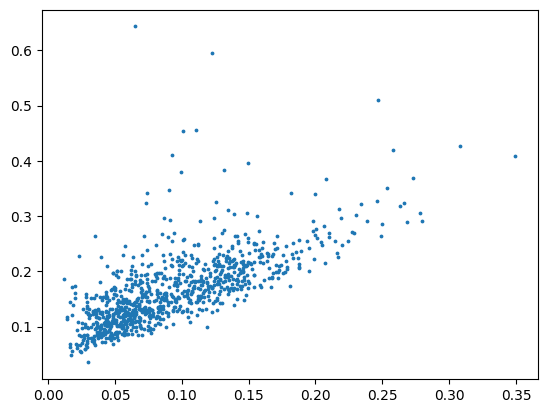

In [148]:
plt.scatter(parsec['lk_dist'][parsec.cluster.isin(baraffe.cluster)], baraffe['lk_dist'][baraffe.cluster.isin(parsec.cluster)], s = 3)

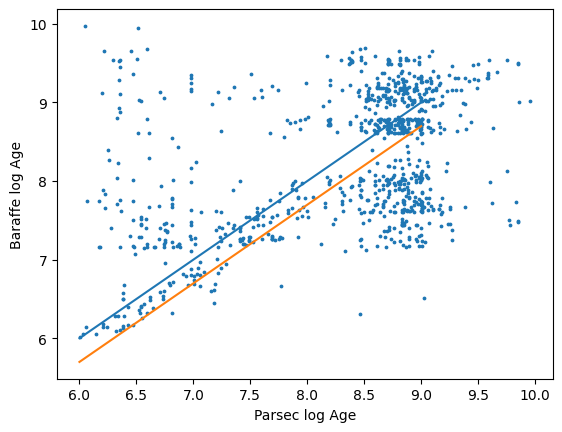

In [149]:
plt.scatter(np.log10(parsec['age'][parsec.cluster.isin(baraffe.cluster)]*10**6), np.log10(baraffe['age'][baraffe.cluster.isin(parsec.cluster)]*10**6), s = 3)
plt.plot(np.arange(6, 10, 1), np.arange(6, 10, 1))
plt.plot(np.arange(6, 10, 1), np.log10((10**np.arange(6, 10, 1))/2))
plt.xlabel('Parsec log Age')
plt.ylabel('Baraffe log Age')
plt.show()

(0.0, 0.4)

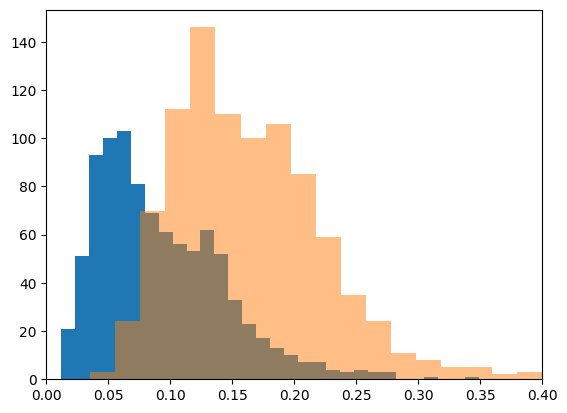

In [150]:
plt.hist(parsec.lk_dist, bins=30)
plt.hist(baraffe.lk_dist, bins=30, alpha=0.5)
plt.xlim(0, 0.4)

In [151]:
baraffe[baraffe.cluster == 'Basel_18']

,cluster,distance,age,av,lk_dist
70,Basel_18,NaN,1430.426379,0.895503,0.195988


In [152]:
parsec[parsec.cluster == 'ASCC_115']

,cluster,distance,age,av,lk_dist
9,ASCC_115,NaN,488.759005,0.786226,0.074814


In [153]:
a = pd.merge(parsec, baraffe, on='cluster', suffixes=('_parsec', '_baraffe'))
a['age_diff'] = a['age_baraffe'] - a['age_parsec']
a

,cluster,distance_parsec,age_parsec,av_parsec,lk_dist_parsec,distance_baraffe,age_baraffe,av_baraffe,lk_dist_baraffe,age_diff
0,ASCC_10,NaN,512.593944,0.421766,0.045408,NaN,506.036810,0.457462,0.147899,-6.557133
1,ASCC_101,NaN,291.507046,0.172539,0.029566,NaN,110.001459,0.031673,0.097514,-181.505588
2,ASCC_105,NaN,512.540353,0.603511,0.055990,NaN,96.033294,0.460539,0.120382,-416.507060
3,ASCC_107,NaN,515.911158,1.510344,0.115640,NaN,98.832834,0.945778,0.181677,-417.078324
4,ASCC_108,NaN,466.158089,0.343920,0.075360,NaN,1204.450827,0.166699,0.109287,738.292738
...,...,...,...,...,...,...,...,...,...,...
912,UPK_93,NaN,732.892712,0.017863,0.050650,NaN,3657.187813,0.131540,0.157726,2924.295101
913,UPK_94,NaN,512.737894,0.966981,0.080893,NaN,552.954531,0.807450,0.192219,40.216638
914,UPK_99,NaN,409.023699,0.293348,0.062772,NaN,938.821491,0.162718,0.209783,529.797791
915,Waterloo_7,NaN,700.259247,0.737646,0.131855,NaN,78.262132,0.103107,0.275678,-621.997115


In [154]:
a.dropna(subset='age_diff', inplace=True)
a.sort_values(by='age_diff', ascending=False, inplace=True)

In [155]:
a[a['age_diff'] > 0][:30]

,cluster,distance_parsec,age_parsec,av_parsec,lk_dist_parsec,distance_baraffe,age_baraffe,av_baraffe,lk_dist_baraffe,age_diff
501,NGC_654,NaN,1.108848,0.042196,0.112722,NaN,9422.015481,0.002894,0.132303,9420.906632
257,King_20,NaN,3.251157,0.249419,0.189375,NaN,8870.155508,0.082413,0.237131,8866.904350
258,King_4,NaN,3.900182,0.188762,0.167239,NaN,4831.621664,0.495060,0.228499,4827.721482
43,Alessi_24,NaN,320.974654,0.226165,0.045589,NaN,4882.253345,0.368949,0.080138,4561.278691
74,Berkeley_60,NaN,1.629650,0.294550,0.218896,NaN,4560.203433,0.087099,0.297244,4558.573783
508,NGC_6664,NaN,2.848330,0.226052,0.147138,NaN,4487.565842,0.136460,0.176723,4484.717512
614,Ruprecht_98,NaN,292.644753,0.644473,0.058250,NaN,4746.157436,0.566284,0.150779,4453.512682
882,UPK_579,NaN,244.941793,0.231758,0.075610,NaN,4408.663080,0.147806,0.126378,4163.721287
230,Harvard_10,NaN,644.898196,0.179408,0.050620,NaN,4487.301799,0.031611,0.107550,3842.403603
109,COIN-Gaia_8,NaN,150.525269,0.420812,0.118804,NaN,3875.183659,0.085864,0.178692,3724.658389


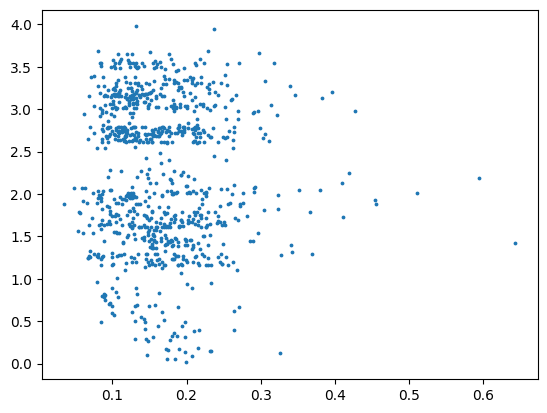

In [156]:
plt.scatter(baraffe['lk_dist'], np.log10(baraffe['age']), s = 3)

(array([ 25.,  28.,  45., 133., 172.,  71., 161., 147., 122.,  13.]),
 array([0.01332816, 0.40940972, 0.80549129, 1.20157285, 1.59765442,
        1.99373599, 2.38981755, 2.78589912, 3.18198068, 3.57806225,
        3.97414381]),
 <BarContainer object of 10 artists>)

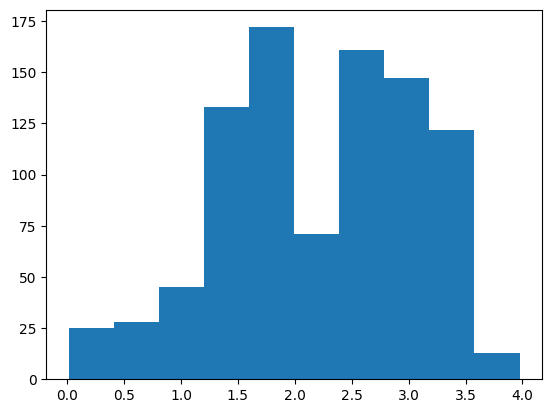

In [157]:
plt.hist(np.log10(baraffe.age))

(array([ 47.,  70.,  55.,  52.,  49.,  49., 230., 321.,  38.,  20.]),
 array([6.00859995, 6.40359998, 6.79860001, 7.19360005, 7.58860008,
        7.98360011, 8.37860014, 8.77360017, 9.1686002 , 9.56360024,
        9.95860027]),
 <BarContainer object of 10 artists>)

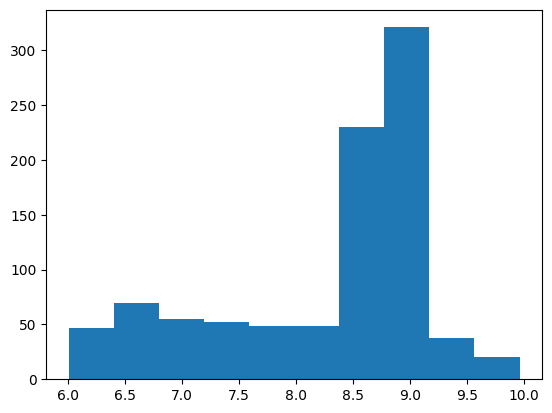

In [159]:
plt.hist(np.log10(parsec.age*10**6))